In [2]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np
import os


In [3]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.6.0


In [4]:
# Check and display the number of GPUs available for model training

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [5]:
# Define constants for image preprocessing, batching, and training parameters

IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 300

In [5]:
import cv2
import shutil
import os
import numpy as np

# Path to the main folder containing disease subfolders
dataset_path = 'Cassava-plant-disease-images'  # Specify the path to the dataset folder
no_leaf_folder = 'no_leaf_images'  # Directory to store images without leaves
leaf_folder = 'leaf_images'  # Directory to store images with leaves

# Create necessary folders if they do not exist
os.makedirs(no_leaf_folder, exist_ok=True)
os.makedirs(leaf_folder, exist_ok=True)

# Function to determine if an image contains a leaf based on green color detection
def contains_leaf(image_path):
    # Load the image
    img = cv2.imread(image_path)

    # Convert the image from BGR to HSV color space
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Define the HSV range for detecting green color (typical for leaves)
    lower_green = np.array([35, 40, 40])  # Lower bound of green color in HSV
    upper_green = np.array([85, 255, 255])  # Upper bound of green color in HSV

    # Create a mask to isolate green regions in the image
    mask = cv2.inRange(hsv, lower_green, upper_green)

    # Sum the pixels in the mask to quantify the green area
    green_area = np.sum(mask)  # Total number of green pixels

    # If the green area exceeds a certain threshold, it is assumed to be a leaf
    if green_area > 2048000:
        # Optionally, apply edge detection to refine leaf detection
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        edges = cv2.Canny(blurred, threshold1=50, threshold2=150)
        edge_pixels = np.sum(edges > 0)  # Count edge pixels

        # If the number of edge pixels exceeds a threshold, classify the image as containing a leaf
        if edge_pixels > 1000:
            return True  # Likely contains a leaf

    # If no significant green area or edges detected, classify as non-leaf image
    return False

# Iterate through all subfolders in the main dataset folder
for subfolder in os.listdir(dataset_path):
    subf


'\nimport cv2\n\nimport shutil\n\n# Path to the main folder containing disease subfolders\ndataset_path = \'Cassava-plant-disease-images\'  # Replace with the path to your folder\nno_leaf_folder = \'no_leaf_images\'  # Folder to store images without leaves\nleaf_folder = \'leaf_images\'  # Folder to store images with leaves\n\n# Create the folders if they do not exist\nos.makedirs(no_leaf_folder, exist_ok=True)\nos.makedirs(leaf_folder, exist_ok=True)\n\n# Function to check if an image contains a leaf\ndef contains_leaf(image_path):\n    # Load the image\n    img = cv2.imread(image_path)\n\n    # Convert the image to the HSV color space\n    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)\n\n    # Define the range for green color in HSV space\n    lower_green = np.array([35, 40, 40])  # Lower bound of green\n    upper_green = np.array([85, 255, 255])  # Upper bound of green\n\n    # Create a mask to detect green regions in the image\n    mask = cv2.inRange(hsv, lower_green, upper_green)\n\n

In [ ]:
import shutil
import os
import random

# Define the paths to the original data directory and the new undersampled dataset directory
original_data_dir = 'leaf_images'
new_data_dir = 'Cassava-plant-disease-images-undersampled'

# Dictionary containing class names and their respective image counts in the original dataset
class_counts = {
    'Cassava___bacterial_blight': 1087,
    'Cassava___brown_streak_disease': 2189,
    'Cassava___green_mottle': 2386,
    'Cassava___healthy': 2577,
    'Cassava___mosaic_disease': 13158,  # The majority class
}

# Determine the size of the smallest class, which will be used as the target size for undersampling
min_class_size = class_counts['Cassava___bacterial_blight']

# Create the directory structure for the new undersampled dataset
for class_name in class_counts:
    # Define the paths for the original and new class folders
    class_path = os.path.join(original_data_dir, class_name)
    new_class_path = os.path.join(new_data_dir, class_name)
    
    # Check if the new class folder exists, and create it if necessary
    if not os.path.exists(new_class_path):
        os.makedirs(new_class_path)

    # List all image files in the original class folder
    image_files = os.listdir(class_path)
    
    # If the class size exceeds the size of the smallest class, undersample the images
    if len(image_files) > min_class_size:
        # Randomly select a subset of images to match the size of the smallest class
        undersampled_images = random.sample(image_files, min_class_size)
    else:
        # If the class size is already equal to or smaller than the minimum size, use all images
        undersampled_images = image_files

    # Copy the undersampled (or all) images to the new class folder in the new dataset directory
    for image in undersampled_images:
        src_image_path = os.path.join(class_path, image)
        dst_image_path = os.path.join(new_class_path, image)
        shutil.copy(src_image_path, dst_image_path)

# Print a completion message indicating the undersampling process is finished
print("Undersampling complete. New dataset created in:", new_data_dir)


In [6]:
# Loading the dataset

dataset_dir = "Cassava-plant-disease-images"
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    'Cassava-plant-disease-images-undersampled',
    shuffle=True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE


)

Found 5423 files belonging to 5 classes.


In [9]:
# Retrieve and display the class names from the dataset for categorization.
class_names = dataset.class_names
class_names

['Cassava___bacterial_blight',
 'Cassava___brown_streak_disease',
 'Cassava___green_mottle',
 'Cassava___healthy',
 'Cassava___mosaic_disease']

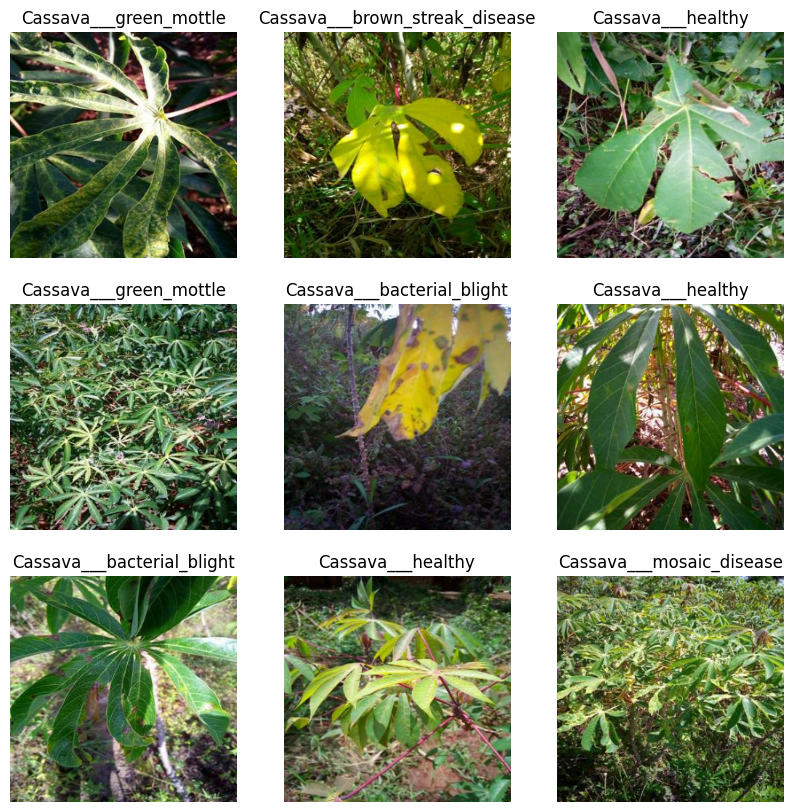

In [10]:
# Visualize a sample of the images from the dataset along with their labels.

plt.figure(figsize=(10,10))
for image_batch, label_batch in dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.axis("off")
        plt.title(class_names[label_batch[i]])

In [11]:
# Display the total number of batches in the dataset.
len(dataset)

170

In [12]:
# Function to split the dataset into training, validation, and test sets.

def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=1000):
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12) # Shuffle the dataset for randomness in training
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [13]:
# Split the dataset into training, validation, and test partitions.

train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [14]:
# Display the number of batches in the training dataset.
len(train_ds)

136

In [15]:
# Display the number of batches in the validation dataset.
len(val_ds)

17

In [16]:
# Display the number of batches in the testing dataset.
len(test_ds)

17

In [17]:
# Apply caching, shuffling, and prefetching to the datasets for better performance during training.

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [18]:
# Define the preprocessing pipeline that resizes and rescales images to a uniform format.

resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1.0/255)
])


In [19]:
# Define the data augmentation pipeline to apply random transformations to the images.

data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2),
    layers.experimental.preprocessing.RandomZoom(0.2),
    layers.experimental.preprocessing.RandomContrast(0.1),
    
])

In [21]:
# Build the model architecture by stacking convolutional, pooling, and dense layers.

input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = len(class_names)

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(64, (7, 7), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),  # Increased filters
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (7, 7), activation='relu'),  # Increased filters
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(256, (7, 7), activation='relu'),  # Increased filters
    layers.MaxPooling2D((2, 2)),
    layers.GlobalMaxPooling2D(),
    layers.Dense(256, activation='relu'),  # Increased dense layer size
    layers.Dropout(0.5),
    layers.Dense(n_classes, activation='softmax')
])

model.build(input_shape=input_shape)





In [22]:
# Summarize the model architecture to display the number of parameters and layer configurations.

model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential (Sequential)      (32, 256, 256, 3)         0         
_________________________________________________________________
sequential_1 (Sequential)    (32, 256, 256, 3)         0         
_________________________________________________________________
conv2d (Conv2D)              (32, 250, 250, 64)        9472      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (32, 125, 125, 64)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (32, 119, 119, 128)       401536    
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (32, 59, 59, 128)         0         
_________________________________________________________________
conv2d_2 (Conv2D)            (32, 53, 53, 256)        

In [23]:
# Compile the model with the Adam optimizer and sparse categorical crossentropy loss function.

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']

)

In [25]:
# Train the model on the training dataset and validate on the validation dataset.

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
)

Epoch 1/200
136/136 [==============================] - 258s 2s/step - loss: 0.9938 - accuracy: 0.6143 - val_loss: 0.9506 - val_accuracy: 0.6140
Epoch 2/200
136/136 [==============================] - 26s 188ms/step - loss: 1.0045 - accuracy: 0.6030 - val_loss: 1.0235 - val_accuracy: 0.5974
Epoch 3/200
136/136 [==============================] - 26s 190ms/step - loss: 0.9886 - accuracy: 0.6164 - val_loss: 0.9788 - val_accuracy: 0.6103
Epoch 4/200
136/136 [==============================] - 26s 191ms/step - loss: 0.9868 - accuracy: 0.6042 - val_loss: 0.9250 - val_accuracy: 0.6544
Epoch 5/200
136/136 [==============================] - 26s 192ms/step - loss: 0.9920 - accuracy: 0.6134 - val_loss: 0.9409 - val_accuracy: 0.6213
Epoch 6/200
136/136 [==============================] - 26s 192ms/step - loss: 0.9700 - accuracy: 0.6171 - val_loss: 0.9766 - val_accuracy: 0.6213
Epoch 7/200
136/136 [==============================] - 26s 193ms/step - loss: 0.9802 - accuracy: 0.6152 - val_loss: 0.9580 - v

In [26]:
# Evaluate the model performance on the test dataset.

scores = model.evaluate(test_ds)

17/17 [==============================] - 5s 51ms/step - loss: 0.4707 - accuracy: 0.8511


In [27]:
# Calculate precision, recall, and F1 score for the model's predictions on the test set.

from sklearn.metrics import precision_score, recall_score, f1_score

# Initialize lists to store true and predicted labels
y_true = []
y_pred = []

# Iterate over the test dataset to collect true and predicted labels
for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = labels.numpy()
    
    y_pred.extend(predicted_classes)
    y_true.extend(true_classes)

# Convert lists to numpy arrays for metric calculation
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute the metrics
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Precision: 0.8514526412911292
Recall: 0.8511029411764706
F1 Score: 0.8501306797202003


In [28]:
# Store the training and validation accuracy and loss for visualization.

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'Training and Validation Loss')

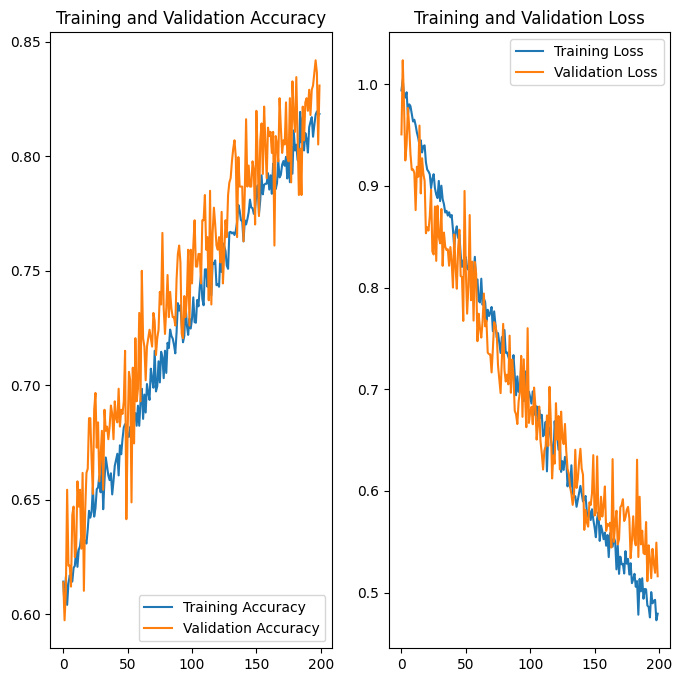

In [29]:
# Visualize the training and validation accuracy and loss over the epochs.

plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label="Training Accuracy")
plt.plot(range(EPOCHS), val_acc, label="Validation Accuracy")
plt.legend(loc='lower right')
plt.title("Training and Validation Accuracy")

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss, label="Training Loss")
plt.plot(range(EPOCHS), val_loss, label="Validation Loss")
plt.legend(loc='upper right')
plt.title("Training and Validation Loss")

first image to predict
actual label:  Cassava___green_mottle
predicted label:  Cassava___brown_streak_disease


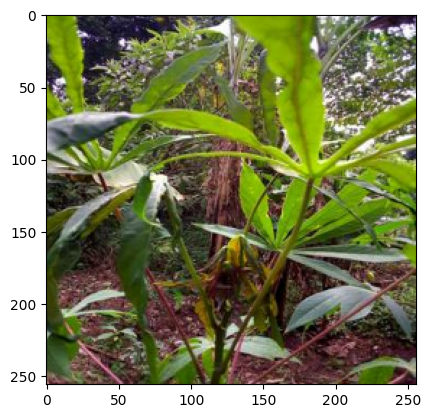

In [37]:
# Display a sample image along with its predicted label for visual inspection.

for images_batch, labels_batch in test_ds.take(1):
    first_image = images_batch[0].numpy().astype('uint8')
    first_label = labels_batch[0].numpy()
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label: ", class_names[first_label])
    
    batch_prediction = model.predict(images_batch)
    print("predicted label: ",class_names[np.argmax(batch_prediction[0])])

In [40]:
# Save the trained model with versioning to manage different model iterations.
models_dir = "../models"  # Adjust the path as necessary

if not os.path.exists(models_dir):
    os.makedirs(models_dir)

model_name = "model_version"

model_version = max(
    [int(i.split('_v')[-1].split('.')[0]) for i in os.listdir(models_dir) if i.startswith(model_name)] + [0]
) + 1

model_save_path = f"{models_dir}/{model_name}_v{model_version}.keras"
model.save(model_save_path)


In [54]:
# Load the .keras model
model = tf.keras.models.load_model('../models/model_version_v1.keras')



In [41]:
scores = model.evaluate(test_ds)

17/17 [==============================] - 1s 52ms/step - loss: 0.4707 - accuracy: 0.8511


In [45]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Assuming `model` is your trained CNN model and `test_ds` is your test dataset
test_labels = []
predicted_labels = []


for images, labels in test_ds:
    # Get model predictions
    predictions = model.predict(images)
    
    # Convert predictions to class labels (taking the index of the max logit)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = labels.numpy()  # Assuming labels are in tensor format
    
    # Append the batch results
    predicted_labels.extend(predicted_classes)
    test_labels.extend(true_classes)

# Convert lists to numpy arrays
test_labels = np.array(test_labels)
predicted_labels = np.array(predicted_labels)

# Calculate precision, recall, and F1 score
precision = precision_score(test_labels, predicted_labels, average='weighted')
recall = recall_score(test_labels, predicted_labels, average='weighted')
f1 = f1_score(test_labels, predicted_labels, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.8514526412911292
Recall: 0.8511029411764706
F1 Score: 0.8501306797202003


In [46]:
precision_per_class = precision_score(test_labels, predicted_labels, average=None)
recall_per_class = recall_score(test_labels, predicted_labels, average=None)
f1_per_class = f1_score(test_labels, predicted_labels, average=None)

print("Precision per class:", precision_per_class)
print("Recall per class:", recall_per_class)
print("F1 Score per class:", f1_per_class)


Precision per class: [0.86813187 0.82442748 0.82727273 0.84       0.90178571]
Recall per class: [0.7979798  0.90756303 0.84259259 0.76363636 0.93518519]
F1 Score per class: [0.83157895 0.864      0.83486239 0.8        0.91818182]
